# Customer Support Ticket Classifier — EDA

End-to-end exploratory analysis of the Multilingual Customer Support Tickets dataset.

**Sections**
1. Data Acquisition
2. Data Cleaning and Preprocessing
   - 2.1 Analysis of Raw Data
   - 2.2 Analysis of Preprocessed Data
3. Exploratory Data Analysis (EDA)
4. Visualizations

All figures are saved to `notebooks/figures/`.

In [1]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA_RAW    = ROOT / "data" / "raw" / "aa_dataset-tickets-multi-lang-5-2-50-version.csv"
DATA_CLEAN  = ROOT / "data" / "processed" / "tickets_clean.csv"
FIGURES_DIR = ROOT / "notebooks" / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

# Column names in the raw CSV (all lowercase)
SUBJECT_COL  = "subject"
BODY_COL     = "body"
LABEL_COL    = "queue"
LANG_COL     = "language"
PRIORITY_COL = "priority"

print(f"Figures will be saved to: {FIGURES_DIR}")

Figures will be saved to: /Users/amulyagupta/ML_projects/AgenticAi/notebooks/figures


---
## 1. Data Acquisition

Load the raw CSV downloaded from [Kaggle — Multilingual Customer Support Tickets](https://www.kaggle.com/datasets/tobiasbueck/multilingual-customer-support-tickets).

If the file is missing, run:
```bash
python src/data/download_data.py
```

In [2]:
raw = pd.read_csv(DATA_RAW)
print(f"Shape: {raw.shape}")
print(f"Columns: {raw.columns.tolist()}")
raw.head(3)

Shape: (28587, 16)
Columns: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN


In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28587 entries, 0 to 28586
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   subject   24749 non-null  object
 1   body      28587 non-null  object
 2   answer    28580 non-null  object
 3   type      28587 non-null  object
 4   queue     28587 non-null  object
 5   priority  28587 non-null  object
 6   language  28587 non-null  object
 7   version   28587 non-null  int64 
 8   tag_1     28587 non-null  object
 9   tag_2     28574 non-null  object
 10  tag_3     28451 non-null  object
 11  tag_4     25529 non-null  object
 12  tag_5     14545 non-null  object
 13  tag_6     5874 non-null   object
 14  tag_7     2040 non-null   object
 15  tag_8     565 non-null    object
dtypes: int64(1), object(15)
memory usage: 3.5+ MB


In [4]:
raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
subject,24749,24749,Wesentlicher Sicherheitsvorfall,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
body,28587,28587,"Sehr geehrtes Support-Team,\n\nich möchte eine...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
answer,28580,28580,Vielen Dank für die Meldung des kritischen Sic...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,28587,4,Incident,11466,NaN,NaN,NaN,NaN,NaN,NaN,NaN
queue,28587,10,Technical Support,8362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
priority,28587,3,medium,11515,NaN,NaN,NaN,NaN,NaN,NaN,NaN
language,28587,2,en,16338,NaN,NaN,NaN,NaN,NaN,NaN,NaN
version,28587.0,NaN,NaN,NaN,278.382027,165.962935,51.0,52.0,400.0,400.0,400.0
tag_1,28587,116,Security,5880,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tag_2,28574,256,Performance,5903,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 2. Data Cleaning and Preprocessing

### 2.1 Analysis of Raw Data

Before any cleaning: inspect null values, duplicates, class balance, and language distribution.

In [5]:
# --- Null values ---
null_pct = (raw.isnull().sum() / len(raw) * 100).sort_values(ascending=False)
print("Null % per column:")
print(null_pct[null_pct > 0].to_string() if null_pct.any() else "No nulls")

Null % per column:
tag_8      98.023577
tag_7      92.863889
tag_6      79.452199
tag_5      49.120229
subject    13.425683
tag_4      10.697170
tag_3       0.475741
tag_2       0.045475
answer      0.024487


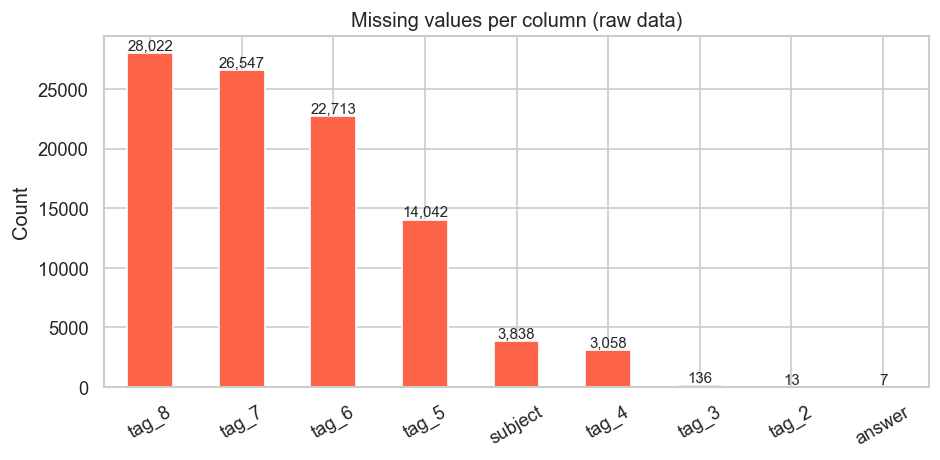

Saved: 01_raw_missing_values.png


In [6]:
# --- Null value heatmap (per column) ---
null_counts = raw.isnull().sum().sort_values(ascending=False)
null_counts = null_counts[null_counts > 0]

fig, ax = plt.subplots(figsize=(8, 4))
null_counts.plot(kind="bar", ax=ax, color="tomato", edgecolor="white")
ax.set_title("Missing values per column (raw data)")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=30)
for p in ax.patches:
    ax.annotate(f"{p.get_height():,.0f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_raw_missing_values.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 01_raw_missing_values.png")

In [7]:
# --- Duplicates ---
dups = raw.duplicated(subset=[BODY_COL, LABEL_COL]).sum()
print(f"Duplicate (body, queue) pairs: {dups}")

# --- Language distribution ---
print(f"\nLanguage distribution:")
print(raw[LANG_COL].value_counts())

# --- Raw class distribution ---
print(f"\nRaw class distribution:")
print(raw[LABEL_COL].value_counts())

Duplicate (body, queue) pairs: 0

Language distribution:
language
en    16338
de    12249
Name: count, dtype: int64

Raw class distribution:
queue
Technical Support                  8362
Product Support                    5252
Customer Service                   4268
IT Support                         3433
Billing and Payments               2788
Returns and Exchanges              1437
Service Outages and Maintenance    1148
Sales and Pre-Sales                 918
Human Resources                     576
General Inquiry                     405
Name: count, dtype: int64


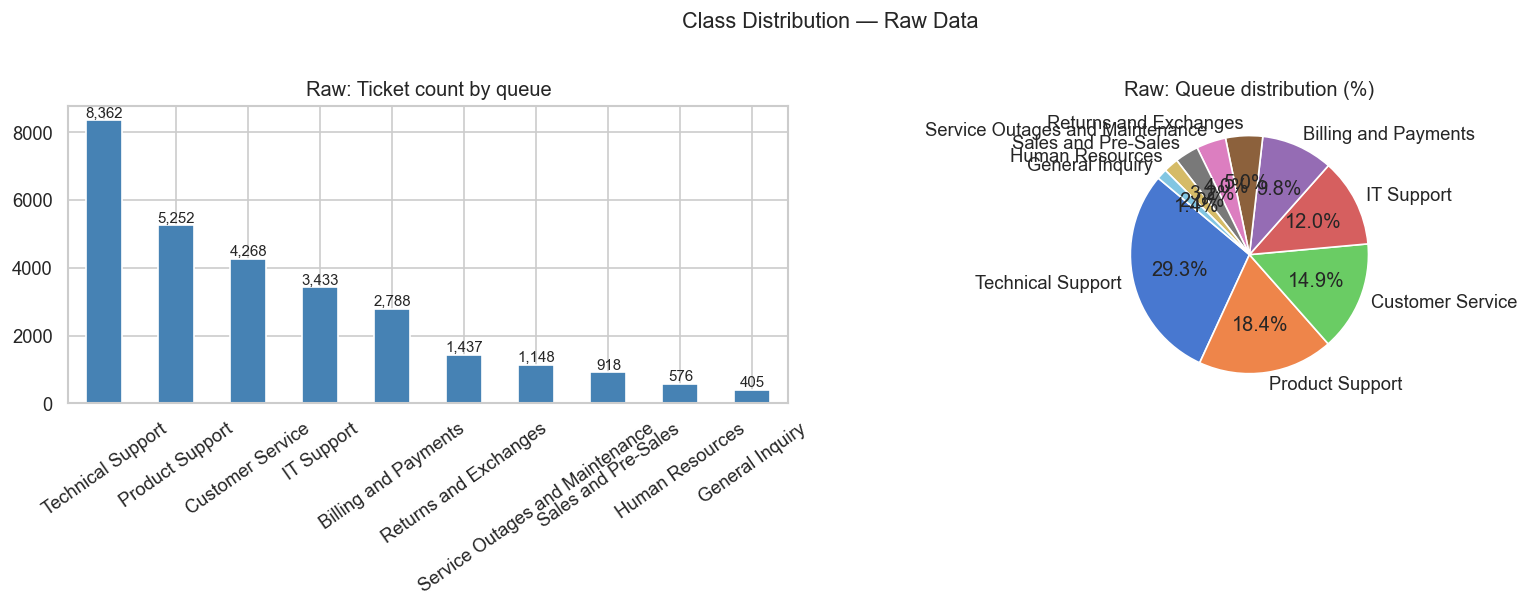

Saved: 02_raw_class_distribution.png


In [8]:
# --- Raw class distribution chart ---
raw_label_counts = raw[LABEL_COL].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

raw_label_counts.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Raw: Ticket count by queue")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=35)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():,}",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontsize=9)

axes[1].pie(raw_label_counts, labels=raw_label_counts.index, autopct="%1.1f%%",
            startangle=140, colors=sns.color_palette("muted", len(raw_label_counts)))
axes[1].set_title("Raw: Queue distribution (%)")

plt.suptitle("Class Distribution — Raw Data", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_raw_class_distribution.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 02_raw_class_distribution.png")

In [9]:
# --- Raw text length stats ---
raw["subject_len"] = raw[SUBJECT_COL].fillna("").apply(len)
raw["body_len"]    = raw[BODY_COL].fillna("").apply(len)
raw["word_count"]  = raw[BODY_COL].fillna("").str.split().str.len()

print("Raw text length statistics:")
raw[["subject_len", "body_len", "word_count"]].describe().round(1)

Raw text length statistics:


,subject_len,body_len,word_count
count,28587.0,28587.0,28587.0
mean,38.5,387.3,53.5
std,23.7,200.1,27.7
min,0.0,6.0,1.0
25%,27.0,219.0,30.0
50%,39.0,386.0,54.0
75%,51.0,551.0,78.0
max,675.0,1469.0,175.0


### 2.2 Analysis of Preprocessed Data

Compare raw data against the cleaned output from `src/data/preprocess.py`.

If `tickets_clean.csv` is missing, run:
```bash
python src/data/preprocess.py
```

In [10]:
if not DATA_CLEAN.exists():
    print(f"File not found: {DATA_CLEAN}")
    print("Run: python src/data/preprocess.py")
else:
    df = pd.read_csv(DATA_CLEAN)
    print(f"Raw rows     : {len(raw):,}")
    print(f"Clean rows   : {len(df):,}")
    print(f"Rows removed : {len(raw) - len(df):,}")
    print(f"\nClean columns: {df.columns.tolist()}")
    df.head(3)

Raw rows     : 28,587
Clean rows   : 16,335
Rows removed : 12,252

Clean columns: ['text', 'label', 'priority', 'language', 'type']


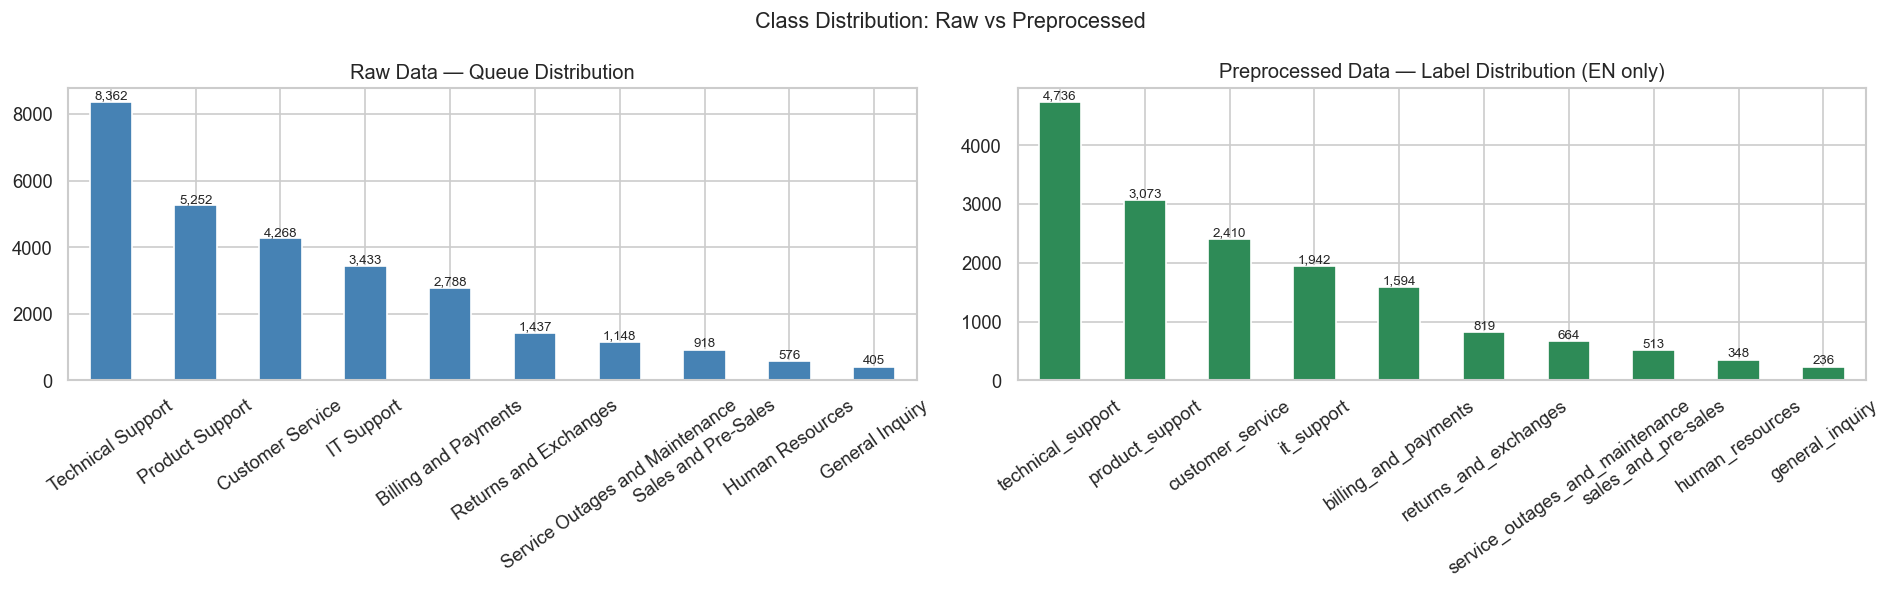

Saved: 03_raw_vs_clean_class_distribution.png


In [11]:
if DATA_CLEAN.exists():
    # Side-by-side raw vs clean class distribution
    raw_dist  = raw[LABEL_COL].value_counts().rename("raw")
    # raw labels are Title Case; clean labels are snake_case — align by mapping
    clean_dist = df["label"].value_counts().rename("clean")

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    raw_dist.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
    axes[0].set_title("Raw Data — Queue Distribution")
    axes[0].tick_params(axis="x", rotation=35)
    axes[0].set_xlabel("")

    clean_dist.plot(kind="bar", ax=axes[1], color="seagreen", edgecolor="white")
    axes[1].set_title("Preprocessed Data — Label Distribution (EN only)")
    axes[1].tick_params(axis="x", rotation=35)
    axes[1].set_xlabel("")

    for ax in axes:
        for p in ax.patches:
            ax.annotate(f"{p.get_height():,}",
                        (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha="center", va="bottom", fontsize=8)

    plt.suptitle("Class Distribution: Raw vs Preprocessed", fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "03_raw_vs_clean_class_distribution.png", bbox_inches="tight", dpi=150)
    plt.show()
    print("Saved: 03_raw_vs_clean_class_distribution.png")

In [12]:
if DATA_CLEAN.exists():
    print("\nClean label distribution:")
    print(df["label"].value_counts().to_string())
    print(f"\nClean text length statistics:")
    df["word_count"] = df["text"].str.split().str.len()
    print(df[["word_count"]].describe().round(1))


Clean label distribution:
label
technical_support                  4736
product_support                    3073
customer_service                   2410
it_support                         1942
billing_and_payments               1594
returns_and_exchanges               819
service_outages_and_maintenance     664
sales_and_pre-sales                 513
human_resources                     348
general_inquiry                     236

Clean text length statistics:
       word_count
count     16335.0
mean         58.3
std          26.6
min           1.0
25%          36.0
50%          60.0
75%          82.0
max         175.0


---
## 3. Exploratory Data Analysis (EDA)

Deeper analysis of text characteristics, priority patterns, and language × queue relationships.

In [13]:
# Text length stats by queue category (raw, English only)
en_raw = raw[raw[LANG_COL] == "en"].copy()
en_raw["word_count"] = en_raw[BODY_COL].fillna("").str.split().str.len()

print("Word count statistics by queue (English raw tickets):")
print(en_raw.groupby(LABEL_COL)["word_count"].describe().round(1).to_string())

Word count statistics by queue (English raw tickets):
                                  count  mean   std  min   25%   50%   75%    max
queue                                                                            
Billing and Payments             1595.0  54.6  27.1  2.0  30.0  56.0  78.0  157.0
Customer Service                 2410.0  54.0  27.1  2.0  31.0  56.0  78.0  166.0
General Inquiry                   236.0  57.9  26.5  2.0  35.0  66.0  82.0   98.0
Human Resources                   348.0  51.5  27.8  2.0  28.0  50.0  77.0  107.0
IT Support                       1942.0  53.6  26.6  3.0  32.0  55.0  77.0  144.0
Product Support                  3073.0  53.4  26.9  2.0  31.0  54.0  77.0  148.0
Returns and Exchanges             820.0  52.9  28.3  2.0  26.8  54.0  77.2  168.0
Sales and Pre-Sales               513.0  52.9  27.8  2.0  27.0  57.0  79.0  124.0
Service Outages and Maintenance   664.0  53.3  27.4  2.0  29.0  57.0  77.0  129.0
Technical Support                4737.0  54.

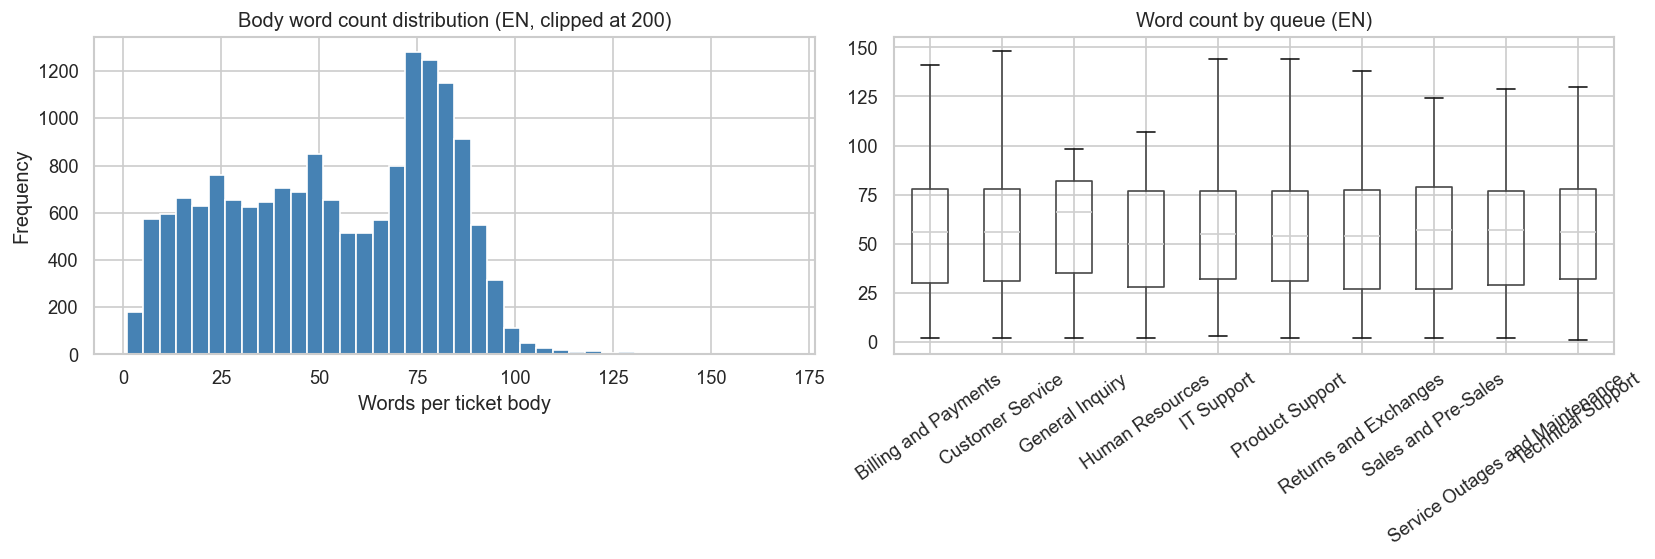

Saved: 04_text_length_distribution.png


In [14]:
# Word count distribution + per-class boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(en_raw["word_count"].clip(upper=200), bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Body word count distribution (EN, clipped at 200)")
axes[0].set_xlabel("Words per ticket body")
axes[0].set_ylabel("Frequency")

en_raw.boxplot(column="word_count", by=LABEL_COL, ax=axes[1], showfliers=False)
axes[1].set_title("Word count by queue (EN)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=35)
plt.suptitle("")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_text_length_distribution.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 04_text_length_distribution.png")

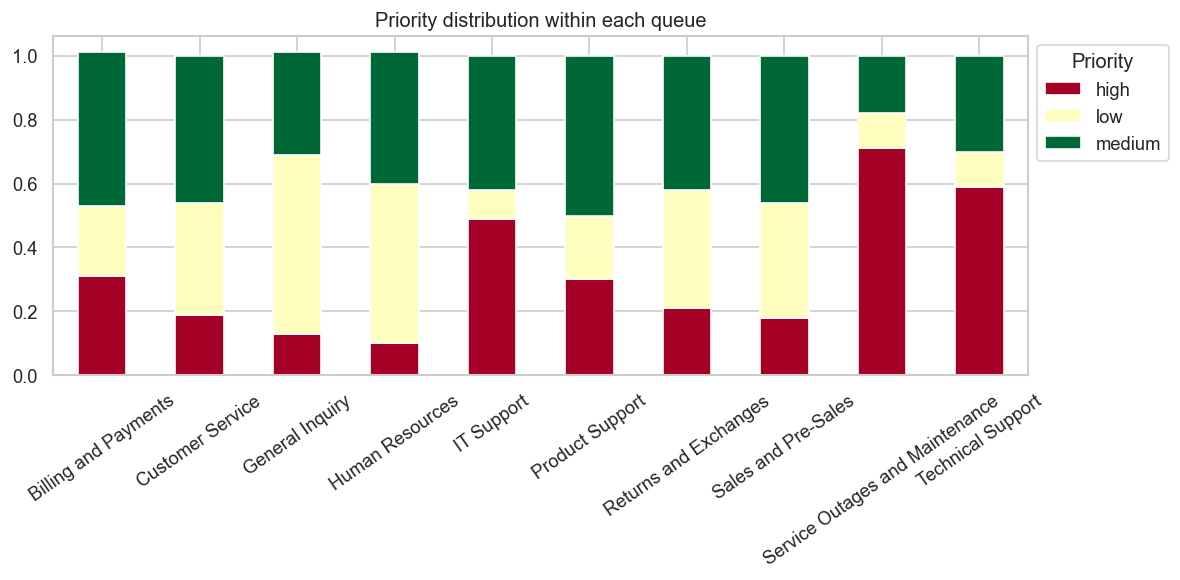

Saved: 05_priority_by_queue.png
priority                         high   low  medium
queue                                              
Billing and Payments             0.31  0.22    0.48
Customer Service                 0.19  0.35    0.46
General Inquiry                  0.13  0.56    0.32
Human Resources                  0.10  0.50    0.41
IT Support                       0.49  0.09    0.42
Product Support                  0.30  0.20    0.50
Returns and Exchanges            0.21  0.37    0.42
Sales and Pre-Sales              0.18  0.36    0.46
Service Outages and Maintenance  0.71  0.11    0.18
Technical Support                0.59  0.11    0.30


In [15]:
# Priority distribution within each queue
if PRIORITY_COL in raw.columns:
    ct = pd.crosstab(raw[LABEL_COL], raw[PRIORITY_COL], normalize="index").round(2)

    fig, ax = plt.subplots(figsize=(10, 5))
    ct.plot(kind="bar", stacked=True, ax=ax, colormap="RdYlGn")
    ax.set_title("Priority distribution within each queue")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=35)
    ax.legend(title="Priority", bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "05_priority_by_queue.png", bbox_inches="tight", dpi=150)
    plt.show()
    print("Saved: 05_priority_by_queue.png")
    print(ct)

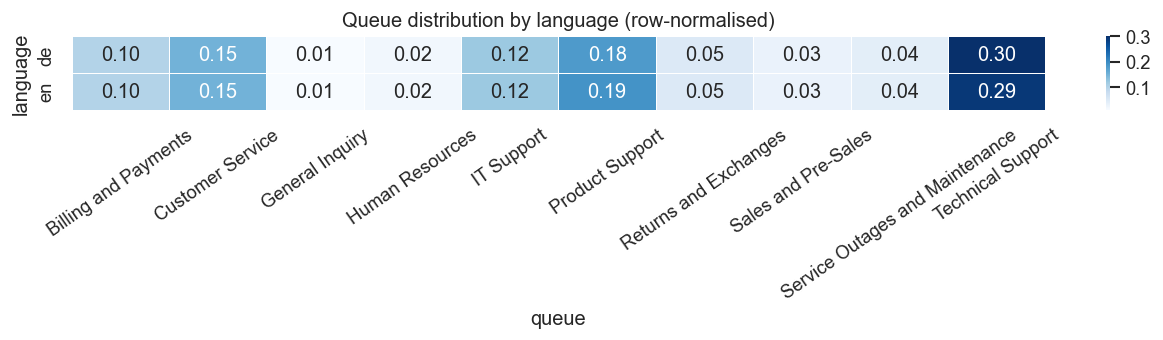

Saved: 06_language_queue_heatmap.png


In [16]:
# Language × Queue heatmap — does language affect routing?
lang_queue = pd.crosstab(raw[LANG_COL], raw[LABEL_COL], normalize="index").round(2)

fig, ax = plt.subplots(figsize=(11, 3))
sns.heatmap(lang_queue, annot=True, fmt=".2f", cmap="Blues", ax=ax, linewidths=0.5)
ax.set_title("Queue distribution by language (row-normalised)")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_language_queue_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 06_language_queue_heatmap.png")

---
## 4. Visualizations

Model-oriented visualizations: discriminative keywords per class and vocabulary overlap.

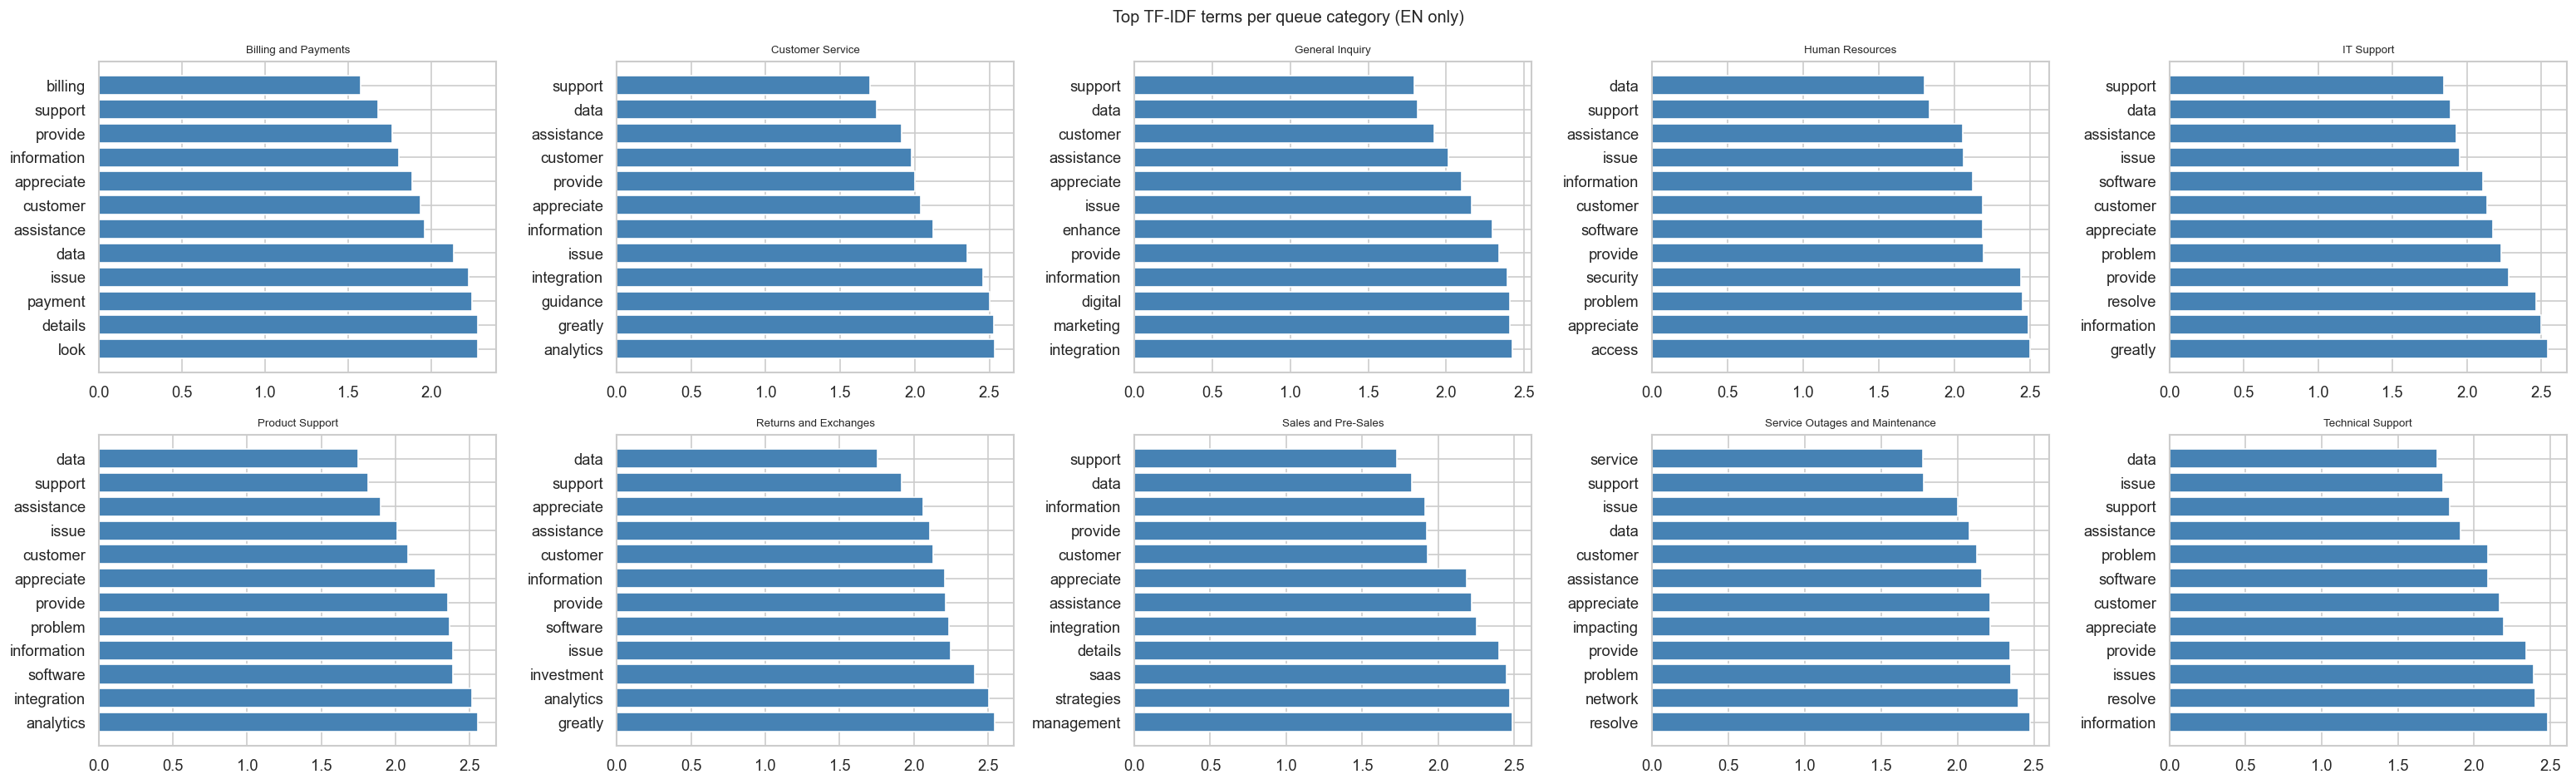

Saved: 07_tfidf_keywords_per_category.png


In [17]:
# Helper: light text cleaning (mirrors preprocess.py)
def clean_text(t):
    t = str(t).lower()
    t = t.encode("ascii", errors="ignore").decode()
    t = re.sub(r"[^\w\s]", " ", t)
    return re.sub(r"\s+", " ", t).strip()

en_raw = raw[raw[LANG_COL] == "en"].copy()
en_raw["clean"] = (en_raw[SUBJECT_COL].fillna("") + " " + en_raw[BODY_COL].fillna("")).apply(clean_text)

categories = sorted(en_raw[LABEL_COL].unique())
TOP_N = 12

fig, axes = plt.subplots(2, 5, figsize=(26, 8), sharey=False)
axes = axes.flatten()

for ax, cat in zip(axes, categories):
    subset = en_raw[en_raw[LABEL_COL] == cat]["clean"]
    tfidf = TfidfVectorizer(max_features=500, stop_words="english", ngram_range=(1, 1))
    tfidf.fit_transform(subset)
    scores = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))
    top = sorted(scores.items(), key=lambda x: x[1])[:TOP_N]
    words, vals = zip(*top)
    ax.barh(words, vals, color="steelblue")
    ax.set_title(cat, fontsize=8)
    ax.invert_yaxis()

# hide unused axes
for ax in axes[len(categories):]:
    ax.set_visible(False)

plt.suptitle("Top TF-IDF terms per queue category (EN only)", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_tfidf_keywords_per_category.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 07_tfidf_keywords_per_category.png")

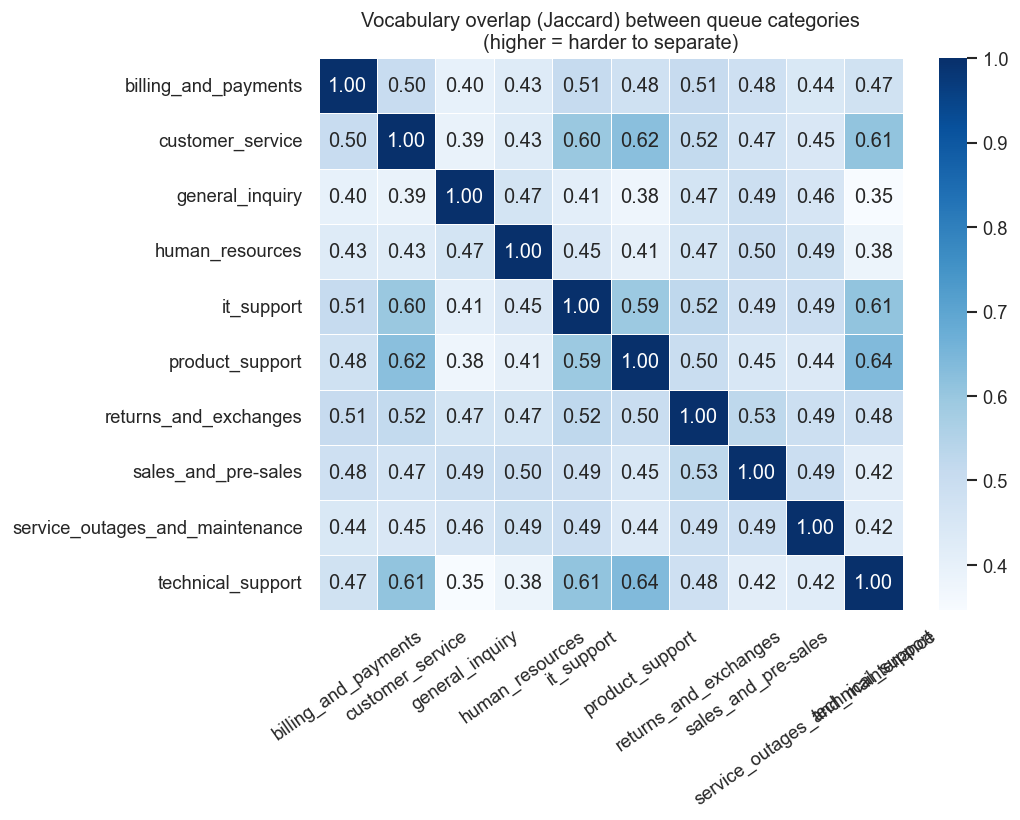

Saved: 08_vocab_overlap_jaccard.png


In [18]:
# Vocabulary overlap (Jaccard) between classes on the clean dataset
if DATA_CLEAN.exists():
    vocab_per_class = {}
    for lbl, grp in df.groupby("label"):
        vocab_per_class[lbl] = set(" ".join(grp["text"]).split())

    labels = sorted(vocab_per_class.keys())
    overlap = pd.DataFrame(index=labels, columns=labels, dtype=float)
    for a in labels:
        for b in labels:
            if a == b:
                overlap.loc[a, b] = 1.0
            else:
                inter = vocab_per_class[a] & vocab_per_class[b]
                union = vocab_per_class[a] | vocab_per_class[b]
                overlap.loc[a, b] = len(inter) / len(union) if union else 0

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(overlap.astype(float), annot=True, fmt=".2f", cmap="Blues", ax=ax, linewidths=0.5)
    ax.set_title("Vocabulary overlap (Jaccard) between queue categories\n(higher = harder to separate)")
    ax.tick_params(axis="x", rotation=35)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "08_vocab_overlap_jaccard.png", bbox_inches="tight", dpi=150)
    plt.show()
    print("Saved: 08_vocab_overlap_jaccard.png")

In [19]:
# List all saved figures
print("Figures saved to:", FIGURES_DIR)
for f in sorted(FIGURES_DIR.glob("*.png")):
    print(f"  {f.name}")

Figures saved to: /Users/amulyagupta/ML_projects/AgenticAi/notebooks/figures
  01_raw_missing_values.png
  02_raw_class_distribution.png
  03_raw_vs_clean_class_distribution.png
  04_text_length_distribution.png
  05_priority_by_queue.png
  06_language_queue_heatmap.png
  07_tfidf_keywords_per_category.png
  08_vocab_overlap_jaccard.png


---
## Summary

**Key takeaways before modeling:**

| Topic | Finding |
|---|---|
| Dataset size | 28,587 raw rows; 16,338 English |
| Languages | English (57%) and German (43%) only |
| Classes | 10 routing queues, moderately imbalanced |
| Missing data | `tag_*` columns heavily sparse; `subject` 13% missing — fill with empty string |
| Text length | Median body ~54 words; consistent across categories |
| Class overlap | High Jaccard overlap suggests TF-IDF bigrams and calibrated classifiers will matter |
| Priority | Relatively uniform across queues — low predictive value alone |
| Language effect | Queue distribution is similar across EN/DE — language filter is mainly for consistency |

Next step: build the feature store → `python -m src.features.feature_store`